## Code to run linear and polynomial regression on the algae bloom data

### <b>Load necessary packages</b>

In [306]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix

%matplotlib inline

### <b>Set file info </b>

In [307]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### <b>Read in algae bloom data</b>

In [308]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [309]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_year,vct_day_of_year,vct_latitude,vct_longitude,vct_water_temp_7days,vct_water_surface_7days,vct_target_bloom_intensity_7days,vct_anabaena_7days,...,noaa_wind_direction_5_min,noaa_air_temp_mean,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,2014,273,44.484736,-73.288936,68.240,1.516667,1.550000,0.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1.000
1,Main Lake Central,2014-10-02,2014,275,44.484736,-73.288936,68.240,1.220000,1.550000,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3.000
2,Main Lake Central,2015-06-14,2015,165,44.484736,-73.288936,70.175,1.125000,1.821429,1.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1.125
3,Main Lake Central,2015-06-15,2015,166,44.484736,-73.288936,68.090,1.200000,1.696429,1.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1.000
4,Main Lake Central,2015-06-16,2015,167,44.484736,-73.288936,65.690,1.400000,1.553571,1.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1.000


### <b>Clean up and format columns</b>

In [310]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

53


Index(['vct_region', 'vct_report_date', 'vct_year', 'vct_day_of_year',
       'vct_latitude', 'vct_longitude', 'vct_water_temp_7days',
       'vct_water_surface_7days', 'vct_target_bloom_intensity_7days',
       'vct_anabaena_7days', 'vct_aphanizomenon_7days',
       'vct_microcystin_7days', 'vct_oscillatoria_7days',
       'vct_target_bloom_7days', 'vct_water_temp_14days',
       'vct_water_surface_14days', 'vct_target_bloom_intensity_14days',
       'vct_anabaena_14days', 'vct_aphanizomenon_14days',
       'vct_microcystin_14days', 'vct_oscillatoria_14days',
       'vct_target_bloom_14days', 'usgs_water_temp_max_7days',
       'usgs_water_temp_min_7days', 'usgs_water_temp_mean_7days',
       'usgs_conductivity_max_7days', 'usgs_conductivity_min_7days',
       'usgs_conductivity_mean_7days', 'usgs_water_temp_max_14days',
       'usgs_water_temp_min_14days', 'usgs_water_temp_mean_14days',
       'usgs_conductivity_max_14days', 'usgs_conductivity_min_14days',
       'usgs_conductivity_m

In [311]:
# Convert columns to floats, integers, and dates as appropriate

algae_numcols_df = algae_raw_df.copy()

date_cols = ["vct_report_date"]

string_cols = ["vct_region"]

integer_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_target_bloom",
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_day_of_year",
    "vct_year"
]

# Format date columns
algae_numcols_df[date_cols] = (
    algae_numcols_df[date_cols]
    .apply(pd.to_datetime, errors="coerce")
)

# Format string columns
algae_numcols_df[string_cols] = algae_numcols_df[string_cols].astype("string")

# Format integer columns (nullable)
algae_numcols_df[integer_cols] = (
    algae_numcols_df[integer_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")
)

# Format all remaining columns as floats
float_cols = algae_numcols_df.columns.difference(string_cols + integer_cols + date_cols)

algae_numcols_df[float_cols] = (
    algae_numcols_df[float_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
)

In [312]:
# Figure out baseline bloom percentage

total_records = len(algae_numcols_df)
records_with_blooms = len(algae_numcols_df[algae_numcols_df["vct_target_bloom"] == 1])
percent_blooms = records_with_blooms / total_records

print(percent_blooms)

0.24289140116478247


### <b>Define the file structure</b>

In [313]:
# Inspect the data and output the structure to a file

algae_model_df = algae_numcols_df.copy()

summary = pd.DataFrame({
    "dtype": algae_model_df.dtypes,
    "non_null": algae_model_df.notnull().sum(),
    "null": algae_model_df.isnull().sum(),
    "pct_null": (algae_model_df.isnull().mean()*100).round(2)
})

structure_summary = summary.sort_values("pct_null", ascending=False)

structure_summary.to_csv(r"..\data\merged_csvs\dataset_structure_summary_with_nulls.csv")

In [314]:
# Define column types

target_cols = ["vct_target_bloom", "vct_target_bloom_intensity"]

meta_cols = ["vct_report_date", "vct_year"]

exclude_cols = ["vct_region", "vct_latitude", "vct_longitude"]

trailing_7day_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_water_temp_7days",
    "vct_water_surface_7days",
    "usgs_conductivity_mean_7days",
    "usgs_water_temp_mean_7days"
]

trailing_14day_cols = [
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_water_temp_14days",
    "vct_water_surface_14days",
    "usgs_conductivity_mean_14days",
    "usgs_water_temp_mean_14days"
]

trailing_target_cols = [
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_target_bloom_intensity_7days",
    "vct_target_bloom_intensity_14days"
]

correlated_cols = ["dec_temperature", 
                   "usgs_water_temp_max_7days", "usgs_water_temp_min_7days",
                   "usgs_water_temp_max_14days", "usgs_water_temp_min_14days",
                   "usgs_conductivity_max_7days", "usgs_conductivity_min_7days",
                   "usgs_conductivity_max_14days", "usgs_conductivity_min_14days",
                   "noaa_air_temp_max", "noaa_air_temp_min"]

# Include only 7-day trailing cols in features
# And do not include trailing_target_cols in features yet
other_cols = algae_model_df.columns.difference(meta_cols + correlated_cols + trailing_7day_cols + trailing_14day_cols + trailing_target_cols + target_cols + exclude_cols)
feature_cols = trailing_7day_cols + list(other_cols)

In [315]:
feature_cols

['vct_anabaena_7days',
 'vct_aphanizomenon_7days',
 'vct_microcystin_7days',
 'vct_oscillatoria_7days',
 'vct_water_temp_7days',
 'vct_water_surface_7days',
 'usgs_conductivity_mean_7days',
 'usgs_water_temp_mean_7days',
 'dec_chlorophyll-a',
 'dec_dissolved phosphorus',
 'dec_secchi depth',
 'dec_total nitrogen',
 'dec_total phosphorus',
 'noaa_air_temp_mean',
 'noaa_precipitation',
 'noaa_snow_depth',
 'noaa_snowfall',
 'noaa_wind_direction_2_min',
 'noaa_wind_direction_5_min',
 'noaa_wind_speed_2_min',
 'noaa_wind_speed_5_min',
 'noaa_wind_speed_mean',
 'vct_day_of_year']

### <b>Split the data into training and test sets</b>

In [316]:
# Create train set and test sets

# We changed the split to hold out 2021 and 2022 for testing, instead of doing a random split
# lr_train_set, lr_test_set = train_test_split(algae_model_df, test_size=0.2, random_state=17)

# Define years to hold out for testing
test_years = [2021, 2022]

# Training set should be all rows *not* in the test years
lr_train_set = algae_model_df[~algae_model_df["vct_year"].isin(test_years)].copy()

# Test set should be all rows *in* the test years
lr_test_set = algae_model_df[algae_model_df["vct_year"].isin(test_years)].copy()

print("Train set:", len(lr_train_set))
print("Test set:", len(lr_test_set))

Train set: 2132
Test set: 787


### <b>Create feature, target, and meta data</b>

##### Create feature, target, and meta data for training data

In [317]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_train_features = lr_train_set[feature_cols].copy()
algae_train_target_bloom = lr_train_set["vct_target_bloom"].copy()
algae_train_target_intensity = lr_train_set["vct_target_bloom_intensity"].copy()
algae_train_meta = lr_train_set[meta_cols].copy()

# Force all feature columns to be numeric

X_train_features_df = algae_train_features.apply(pd.to_numeric, errors="coerce")

In [318]:
# Print out columns that have NaNs

cols_with_nans = X_train_features_df.columns[X_train_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_train_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 63 NaNs
usgs_conductivity_mean_7days - 3 NaNs
usgs_water_temp_mean_7days - 2 NaNs
dec_chlorophyll-a - 148 NaNs
dec_dissolved phosphorus - 151 NaNs
dec_secchi depth - 142 NaNs
dec_total nitrogen - 151 NaNs
dec_total phosphorus - 151 NaNs
['vct_water_temp_7days', 'usgs_conductivity_mean_7days', 'usgs_water_temp_mean_7days', 'dec_chlorophyll-a', 'dec_dissolved phosphorus', 'dec_secchi depth', 'dec_total nitrogen', 'dec_total phosphorus']


In [319]:
# Fill in NaN columns with means

X_train_features_df[nan_cols] = X_train_features_df[nan_cols].fillna(X_train_features_df[nan_cols].mean())

# Check to make sure there are no more NaNs
nan_counts = X_train_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [320]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_train_features = X_train_features_df.to_numpy() # converts feature dataframe into an array
y_lr_train_bloom = np.asarray(algae_train_target_bloom) # converts target series into a vector
y_lr_train_intensity = np.asarray(algae_train_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_train_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_train_theta = np.zeros((X_train_features_df.shape[1], 1))

# Print shapes
print("X_train_features_df shape:", X_train_features_df.shape)
print("y_lr_train_bloom shape:", y_lr_train_bloom.shape)
print("y_lr_train_intensity shape:", y_lr_train_intensity.shape)
print("lr_train_theta shape:", lr_train_theta.shape)

X_train_features_df shape: (2132, 23)
y_lr_train_bloom shape: (2132,)
y_lr_train_intensity shape: (2132,)
lr_train_theta shape: (23, 1)


##### Create features, targets, and meta data for test data

In [321]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_test_features = lr_test_set[feature_cols].copy()
algae_test_target_bloom = lr_test_set["vct_target_bloom"].copy()
algae_test_target_intensity = lr_test_set["vct_target_bloom_intensity"].copy()
algae_test_meta = lr_test_set[meta_cols].copy()

# Force all feature columns to be numeric

X_test_features_df = algae_test_features.apply(pd.to_numeric, errors="coerce")

In [322]:
# Print out columns that have NaNs

cols_with_nans = X_test_features_df.columns[X_test_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_test_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 58 NaNs
dec_chlorophyll-a - 104 NaNs
dec_dissolved phosphorus - 95 NaNs
dec_secchi depth - 95 NaNs
dec_total nitrogen - 95 NaNs
dec_total phosphorus - 95 NaNs
['vct_water_temp_7days', 'dec_chlorophyll-a', 'dec_dissolved phosphorus', 'dec_secchi depth', 'dec_total nitrogen', 'dec_total phosphorus']


In [323]:
# Fill in NaN columns with means

X_test_features_df[nan_cols] = X_test_features_df[nan_cols].fillna(X_test_features_df[nan_cols].mean())

# Check to make sure there are no more NaNs
nan_counts = X_test_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [324]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_test_features = X_test_features_df.to_numpy() # converts feature dataframe into an array
y_lr_test_bloom = np.asarray(algae_test_target_bloom) # converts target series into a vector
y_lr_test_intensity = np.asarray(algae_test_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_test_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_test_theta = np.zeros((X_test_features_df.shape[1], 1))

# Print shapes
print("X_test_features_df shape:", X_test_features_df.shape)
print("y_lr_test_bloom shape:", y_lr_test_bloom.shape)
print("y_lr_test_intensity shape:", y_lr_test_intensity.shape)
print("lr_test_theta shape:", lr_test_theta.shape)

X_test_features_df shape: (787, 23)
y_lr_test_bloom shape: (787,)
y_lr_test_intensity shape: (787,)
lr_test_theta shape: (23, 1)


### <b>Scale the feature data</b>

##### Scale the training feature data

In [325]:
# Define the scaler
train_scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_lr_train_features_scaled = train_scaler.fit_transform(X_lr_train_features)

# Transform test set using the same scaler:
# X_test_features_scaled = scaler.transform(X_test_features)

# Check the results
print("First 5 rows of scaled features:\n", X_lr_train_features_scaled[:5])
print("Mean of scaled features (should be close to 0):", X_lr_train_features_scaled.mean(axis=0))
print("Std of scaled features (should be 1):", X_lr_train_features_scaled.std(axis=0))

First 5 rows of scaled features:
 [[-1.19625032e+00 -1.02662062e+00 -6.87295927e-01 -3.74308632e-01
  -6.39550322e-01 -8.41880712e-02  0.00000000e+00  1.07447584e-15
  -6.09800394e-01 -8.00747086e-01  1.24251117e+00 -6.52002266e-01
  -6.04856547e-01 -1.63054244e+00 -9.78174215e-01 -5.59943653e-02
  -6.17793090e-02 -2.19817381e+00 -1.74033523e+00 -1.18709986e+00
  -1.12856631e+00 -5.94329408e-01  1.45275999e+00]
 [ 8.35945441e-01 -1.02662062e+00 -6.87295927e-01 -3.74308632e-01
  -6.39550322e-01 -1.24596656e+00 -2.15393231e+00 -1.09194880e+00
  -6.09800394e-01 -8.00747086e-01  1.24251117e+00 -6.52002266e-01
  -6.04856547e-01 -1.60105553e+00 -1.11361842e+00 -5.59943653e-02
  -6.17793090e-02 -1.11554424e+00 -5.95635607e-01 -1.22987335e+00
  -1.33239882e+00 -5.47544373e-01  1.51103877e+00]
 [ 8.35945441e-01 -1.02662062e+00 -6.87295927e-01 -3.74308632e-01
  -3.19910642e-01 -1.61799675e+00 -8.95291186e-02 -2.15480256e+00
  -8.10963314e-01  2.03014165e-01  9.82157846e-01 -1.95124205e-01
   2.6

##### Scale the test feature data

In [326]:
# Define the scaler
test_scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_lr_test_features_scaled = test_scaler.fit_transform(X_lr_test_features)

# Transform test set using the same scaler:
# X_test_features_scaled = scaler.transform(X_test_features)

# Check the results
print("First 5 rows of scaled features:\n", X_lr_test_features_scaled[:5])
print("Mean of scaled features (should be close to 0):", X_lr_test_features_scaled.mean(axis=0))
print("Std of scaled features (should be 1):", X_lr_test_features_scaled.std(axis=0))

First 5 rows of scaled features:
 [[-0.38588225 -1.00637355 -0.86314025 -0.09473309 -0.22923602  3.32186776
  -1.25765979 -0.84359646 -0.72650867 -0.55966856  0.34267567 -0.49938197
  -0.66967591  0.46640347 -0.31649692  0.         -0.05047545  0.93433508
   1.12109925  0.7971626   0.73711692  0.6732597  -1.66105237]
 [-0.38588225 -1.00637355 -0.86314025 -0.09473309  0.12438006  3.14647044
  -1.18960417 -0.84803974 -0.72650867 -0.55966856  0.34267567 -0.49938197
  -0.66967591  0.39622001 -0.32830124  0.         -0.05047545  0.96732246
   1.30895133  0.46666989  0.41359746  0.33935078 -1.63493143]
 [-0.38588225 -1.00637355 -0.86314025 -0.09473309  0.12438006  3.88313918
  -1.05349293 -0.82138006 -0.72650867 -0.55966856  0.34267567 -0.49938197
  -0.66967591  0.32603654 -0.03712788  0.         -0.05047545  0.76939818
   1.34026002  1.03585177  0.97480468  0.61518858 -1.6088105 ]
 [-0.38588225 -1.00637355 -0.86314025 -0.09473309  0.12438006  3.37156367
  -1.14423376 -0.82582334 -0.72650867

### <b>Train the model without cross-validation</b>

##### Train the model on bloom presence (T/F)

In [327]:
# Create the model
lr_bloom_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_bloom_model.fit(X_lr_train_features_scaled, y_lr_train_bloom)

# Check the R2 score on the training set
lr_bloom_train_r2 = lr_bloom_model.score(X_lr_train_features_scaled, y_lr_train_bloom)
print("Training R2:", lr_bloom_train_r2)

# Get predictions from the model
y_pred_bloom_test = lr_bloom_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_bloom_test_r2 = lr_bloom_model.score(X_lr_test_features_scaled, y_lr_test_bloom)
print("Test R2:", lr_bloom_test_r2)

# Print out coefficients and intercept
print("Coefficients:", lr_bloom_model.coef_)
print("Intercept:", lr_bloom_model.intercept_)

Training R2: 0.16782797945342876
Test R2: 0.06421678860434421
Coefficients: [ 0.02109177  0.00697308  0.00827424 -0.01620715  0.01522028  0.00043024
  0.00774763 -0.04734347  0.01315461 -0.04744289 -0.03718391 -0.00126531
  0.13119382  0.07865631 -0.00563266  0.01505342 -0.01712784  0.0237819
  0.00059899 -0.0591656   0.06933445 -0.04603031  0.07936288]
Intercept: 0.2340525328330205


##### Train the model on bloom intensity (continuous)

In [328]:
# Create the model
lr_intensity_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_intensity_model.fit(X_lr_train_features_scaled, y_lr_train_intensity)

# Check the R2 score on the training set
lr_intensity_train_r2 = lr_intensity_model.score(X_lr_train_features_scaled, y_lr_train_intensity)
print("Training R2:", lr_intensity_train_r2)

# Get predictions from the model
y_pred_intensity_test = lr_intensity_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_intensity_test_r2 = lr_intensity_model.score(X_lr_test_features_scaled, y_lr_test_intensity)
print("Test R2:", lr_intensity_test_r2)

# Print out coefficients and intercept
print("Coefficients:", lr_intensity_model.coef_)
print("Intercept:", lr_intensity_model.intercept_)

Training R2: 0.2865201725827333
Test R2: 0.20266621435566123
Coefficients: [ 0.00739363  0.02399607  0.00294618 -0.00257078  0.04495948  0.0030461
 -0.0012135  -0.03686259  0.00801183 -0.08817922 -0.03896122 -0.01692324
  0.27647328  0.05374454 -0.00208561  0.01498121 -0.01906119  0.02624267
 -0.0171424  -0.06746719  0.07634384 -0.05875609  0.07969837]
Intercept: 1.3777799523594334


### <b>Train the model with cross-validation</b>

##### Validate the bloom presence model (T/F)

In [329]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_bloom = LeaveOneGroupOut()

# Create the model
lr_bloom_model = LinearRegression(fit_intercept=True)

# Do cross-validation one year at a time
cv_r2_scores = cross_val_score(
    lr_bloom_model,
    X_lr_train_features_scaled,
    y_lr_train_bloom,
    cv=logo_bloom.split(X_lr_train_features_scaled, y_lr_train_bloom, groups=groups),
    scoring='r2'
)

# Fit the model
lr_bloom_model.fit(X_lr_train_features_scaled, y_lr_train_bloom)

# Check the R2 score on the training set
lr_bloom_train_r2 = lr_bloom_model.score(X_lr_train_features_scaled, y_lr_train_bloom)
print("Training R2:", lr_bloom_train_r2)

# Get predictions from the model
y_pred_bloom_test = lr_bloom_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_bloom_test_r2 = lr_bloom_model.score(X_lr_test_features_scaled, y_lr_test_bloom)
print("Test R2:", lr_bloom_test_r2)

# Print out coefficients and intercept
print("Coefficients:", lr_bloom_model.coef_)
print("Intercept:", lr_bloom_model.intercept_)

Training R2: 0.16782797945342876
Test R2: 0.06421678860434421
Coefficients: [ 0.02109177  0.00697308  0.00827424 -0.01620715  0.01522028  0.00043024
  0.00774763 -0.04734347  0.01315461 -0.04744289 -0.03718391 -0.00126531
  0.13119382  0.07865631 -0.00563266  0.01505342 -0.01712784  0.0237819
  0.00059899 -0.0591656   0.06933445 -0.04603031  0.07936288]
Intercept: 0.2340525328330205


##### Validate the bloom intensity model (continuous)

In [330]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_intensity = LeaveOneGroupOut()

# Create the model
lr_intensity_model = LinearRegression(fit_intercept=True)

# Do cross-validation one year at a time
cv_r2_scores = cross_val_score(
    lr_intensity_model,
    X_lr_train_features_scaled,
    y_lr_train_intensity,
    cv=logo_intensity.split(X_lr_train_features_scaled, y_lr_train_intensity, groups=groups),
    scoring='r2'
)

# Fit the model
lr_intensity_model.fit(X_lr_train_features_scaled, y_lr_train_intensity)

# Check the R2 score on the training set
lr_intensity_train_r2 = lr_intensity_model.score(X_lr_train_features_scaled, y_lr_train_intensity)
print("Training R2:", lr_intensity_train_r2)

# Get predictions from the model
y_pred_intensity_test = lr_intensity_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_intensity_test_r2 = lr_intensity_model.score(X_lr_test_features_scaled, y_lr_test_intensity)
print("Test R2:", lr_intensity_test_r2)

print("CV R2 per year:", cv_r2_scores)
print("Mean CV R2:", np.mean(cv_r2_scores))
print("Standard deviation of CV R^2:", np.std(cv_r2_scores))

# Print out coefficients and intercept
print("Coefficients:", lr_intensity_model.coef_)
print("Intercept:", lr_intensity_model.intercept_)

Training R2: 0.2865201725827333
Test R2: 0.20266621435566123
CV R2 per year: [-0.62070471  0.24776347  0.17228718  0.22621029  0.27822559  0.16440576
  0.09161805]
Mean CV R2: 0.07997223270023325
Standard deviation of CV R^2: 0.29168934808422503
Coefficients: [ 0.00739363  0.02399607  0.00294618 -0.00257078  0.04495948  0.0030461
 -0.0012135  -0.03686259  0.00801183 -0.08817922 -0.03896122 -0.01692324
  0.27647328  0.05374454 -0.00208561  0.01498121 -0.01906119  0.02624267
 -0.0171424  -0.06746719  0.07634384 -0.05875609  0.07969837]
Intercept: 1.3777799523594334


### <b>Calculate performance metrics</b>

##### Accuracy, precision, and recall for bloom presence (T/F)

In [331]:
# Convert regression predictions to binary classes
y_pred_bloom_test_class = (y_pred_bloom_test >= 0.5).astype(int)

# True labels
y_true_bloom = y_lr_test_bloom.astype(int)

# Calculate accuracy
acc = accuracy_score(y_true_bloom, y_pred_bloom_test_class)

# Calculate precision
prec = precision_score(y_true_bloom, y_pred_bloom_test_class, zero_division=0)

# Calculate recall
rec = recall_score(y_true_bloom, y_pred_bloom_test_class)

print(f"Bloom presence\nAccuracy: {acc:.3f}\nPrecision: {prec:.3f}\nRecall: {rec:.3f}")

Bloom presence
Accuracy: 0.755
Precision: 0.589
Recall: 0.267


##### Plot PR curve

In [332]:
# Calculate precision and recall across a range of thresholds
precision, recall, thresholds = precision_recall_curve(
    y_true_bloom,
    y_pred_bloom_test
)

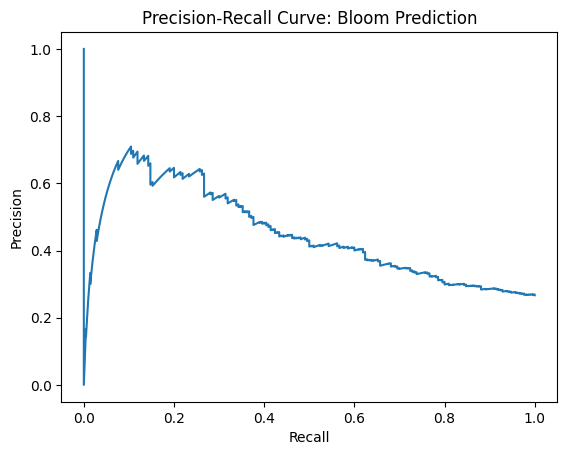

In [333]:
plt.figure()

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Bloom Prediction")

plt.show()

In [334]:
# Calculate AUC for PR curve

pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

PR AUC: 0.4427060972879783


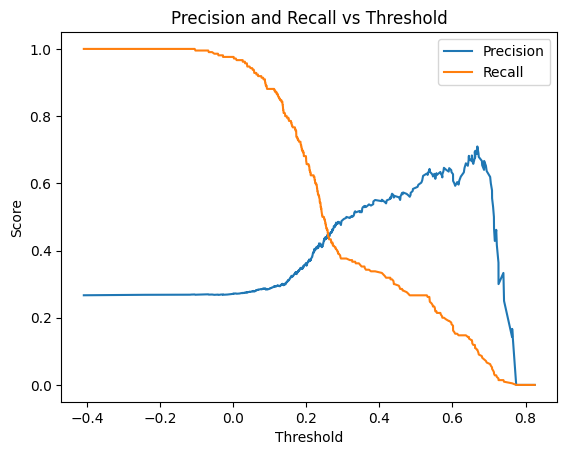

In [335]:
plt.figure()

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")

plt.legend()

In [336]:
# Calculate point where precision and recall points cross

# difference between precision and recall
diff = np.abs(precision[:-1] - recall[:-1])

# index where they are closest
best_idx = np.argmin(diff)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print("Threshold where precision ≈ recall:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)

Threshold where precision ≈ recall: 0.2601341519104201
Precision: 0.44285714285714284
Recall: 0.44285714285714284


In [337]:
# Confusion matrix for precision/recall crossing threshold
# TN FP
# FN TP

threshold = 0.26

# Convert regression predictions to binary classes
y_pred_bloom_test_class = (y_pred_bloom_test >= threshold).astype(int)

# True labels
y_true_bloom = y_lr_test_bloom.astype(int)

# Calculate accuracy
acc = accuracy_score(y_true_bloom, y_pred_bloom_test_class)

# Calculate precision
prec = precision_score(y_true_bloom, y_pred_bloom_test_class, zero_division=0)

# Calculate recall
rec = recall_score(y_true_bloom, y_pred_bloom_test_class)

print(f"Precision-Recall Crossing Threshold of {threshold}\nAccuracy: {acc:.3f}\nPrecision: {prec:.3f}\nRecall: {rec:.3f}\n")
cm = confusion_matrix(y_true_bloom, y_pred_bloom_test_class)
print(cm)

Precision-Recall Crossing Threshold of 0.26
Accuracy: 0.703
Precision: 0.443
Recall: 0.443

[[460 117]
 [117  93]]


In [338]:
# Calculate F1 score

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

best_f1_idx = np.argmax(f1_scores)

best_f1_threshold = thresholds[best_f1_idx]

print("Best F1 threshold:", best_f1_threshold)
print("Best F1:", f1_scores[best_f1_idx])

Best F1 threshold: 0.774478065509792
Best F1: nan


C:\Users\hefla\AppData\Local\Temp\ipykernel_32960\944718141.py:3: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])


In [339]:
# Confusion matrix for best F1 threshold
# TN FP
# FN TP

threshold = 0.774

# Convert regression predictions to binary classes
y_pred_bloom_test_class = (y_pred_bloom_test >= threshold).astype(int)

# True labels
y_true_bloom = y_lr_test_bloom.astype(int)

# Calculate accuracy
acc = accuracy_score(y_true_bloom, y_pred_bloom_test_class)

# Calculate precision
prec = precision_score(y_true_bloom, y_pred_bloom_test_class, zero_division=0)

# Calculate recall
rec = recall_score(y_true_bloom, y_pred_bloom_test_class)

print(f"Best F1 Threshold of {threshold}\nAccuracy: {acc:.3f}\nPrecision: {prec:.3f}\nRecall: {rec:.3f}\n")
cm = confusion_matrix(y_true_bloom, y_pred_bloom_test_class)
print(cm)

Best F1 Threshold of 0.774
Accuracy: 0.727
Precision: 0.000
Recall: 0.000

[[572   5]
 [210   0]]


##### Regression metrics for bloom intensity (continuous)

In [340]:
# Generate predictions on the test set
y_pred_intensity_test = lr_intensity_model.predict(X_lr_test_features_scaled)

# True values
y_true_intensity = y_lr_test_intensity

# Evaluation metrics
r2 = r2_score(y_true_intensity, y_pred_intensity_test)
rmse = np.sqrt(mean_squared_error(y_true_intensity, y_pred_intensity_test))
mae = mean_absolute_error(y_true_intensity, y_pred_intensity_test)

print("Bloom intensity model performance:")
print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")

Bloom intensity model performance:
R²   : 0.203
RMSE : 0.440
MAE  : 0.316


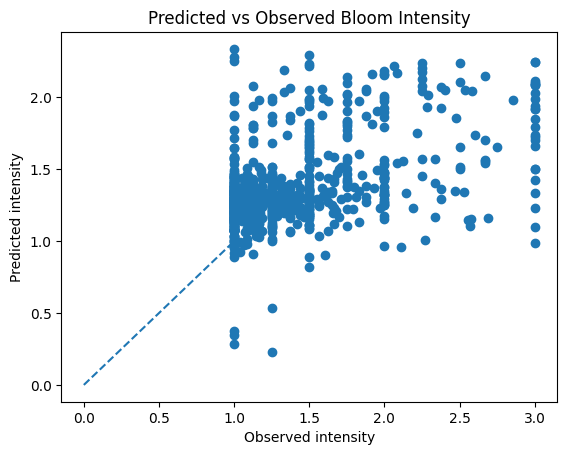

In [341]:
# Scatterplot of predicted vs. actual
plt.scatter(y_lr_test_intensity, y_pred_intensity_test)

plt.xlabel("Observed intensity")
plt.ylabel("Predicted intensity")

plt.title("Predicted vs Observed Bloom Intensity")

plt.plot([0,1],[0,1], linestyle="--")  # perfect prediction line
plt.show()